###### Scatter Plots:
<div style='font-size:14px'>these type of plots are great at showing correlation between multiple variables  

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import numpy as np
import ast

# Loading Data set
dataset= load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df = df[df['job_title_short'] == 'Data Analyst']
df_exploded = df.explode('job_skills')

In [7]:
skills_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills','count'),
    median_salary=('salary_year_avg','median')
)

skills_stats = skills_stats.sort_values(by='skill_count',ascending=False).head(10)

<div style='font-size:14px'>now here in groupby we have made a dict kind of for agg bcz we wnted multiple agg functions on diff columns`

In [5]:
skills_stats

,skill_count,median_salary
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000


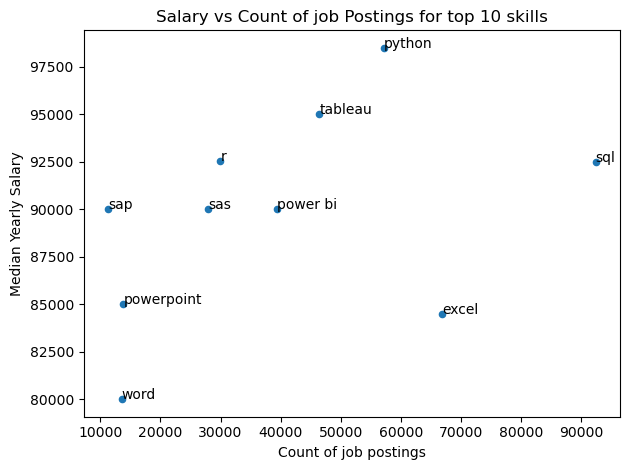

In [8]:
skills_stats.plot(kind='scatter',x='skill_count',y='median_salary')
plt.xlabel('Count of job postings')
plt.ylabel('Median Yearly Salary')
plt.title('Salary vs Count of job Postings for top 10 skills')
plt.tight_layout()

for i, txt in enumerate(skills_stats.index):
    plt.text(skills_stats['skill_count'].iloc[i],skills_stats['median_salary'].iloc[i],txt)

<div style='font-size:14px'>the last loop thing we did is for labling the points we used .txt mehod from python it contains 3 parameters (x value, y value, name of label) so we loop through skill stat and labeled them 